In [1]:
import sys
!{sys.executable} -m pip list | grep -E "ipyleaflet|geopandas|odc|pystac"

geopandas                 1.1.3
ipyleaflet                0.20.0
odc-algo                  1.1.1
odc-geo                   0.5.1
odc-io                    0.2.2
odc-loader                0.6.4
odc-stac                  0.5.2
pystac                    1.14.3
pystac-client             0.9.0


In [2]:
# Imports
# General
import sys                                   # Allows interaction with python (sys and support functions)
import os, re                                # Allows interaction with the operating system (os) and regular expression library (re)

import matplotlib.pyplot as plt              # A plotting module and convention in Python for creating 2D graphs and figures
from matplotlib import colors as mcolours    # A module for handling colours, colourmaps and normalisation.
from matplotlib.patches import Patch         # Allows creation of simple shapes (e.g., rectangles) that can be added to plots (e.g., in a legend)

from PIL import Image                        # The Python Imaging Library (PIL) for access and maniputation of images.
import io                                    # Provides tools for handling data in memory without writing to disk.

import pandas as pd
import geopandas as gpd                      # Loads the GeoPandas library with the alias being gpd.

import numpy as np                           # NumPy handles raw numerical (including multi-dimensional) arrays
import xarray as xr                          # Xarray builds on NumPY but adds labels and metadata (e.g., dimensions, coordinates). 


# ESA Climate Toolbox imports for accessing and plotting ESA CCI data
from esa_climate_toolbox.core import get_op              # Get predefined operations (e.g., time series, averages)
from esa_climate_toolbox.core import list_ecv_datasets   # List available datasets per ECV (Essential Climate Variable)
from esa_climate_toolbox.core import get_store           # Connect to an ESA data store
from esa_climate_toolbox.core import list_datasets       # List all datasets in a store
from esa_climate_toolbox.core import search
from esa_climate_toolbox.ops import plot                 # High-level plotting functions for CCI data
from esa_climate_toolbox.ops import temporal_aggregation

# Used for connecting to remote data sources (e.g., ESA CCI ODP)
from xcube.core.store import new_data_store

# For displaying geographic regions interactively (if desired)
from IPython.display import GeoJSON
import shapely.geometry   # Handling geometric objects like bounding boxes

# Core data science libraries
import pandas as pd       # For tabular data handling and time manipulation
import numpy as np        # For numerical operations
import xarray as xr       # For multi-dimensional climate data structures

# Mapping and plotting
import matplotlib.pyplot as plt       # Plotting library
from matplotlib.colors import TwoSlopeNorm
import cartopy.crs as ccrs            # Cartographic projections for spatial data
import cartopy.feature as cfeature
import rasterio                       # Used to read GeoTIFF files

# Individual colormap creation
from matplotlib.colors import ListedColormap, BoundaryNorm

# Notebook settings
import warnings
warnings.filterwarnings("ignore") # Suppressing warnings to keep notebook output clean
%matplotlib inline

# Import year slider
from display_tools import year_range_slider  # Optional

# DEA 
import odc.stac                              # Part of the Open Data Cube (ODC) ecosystem; this library is designed to work with SpatioTemporal Asset Catalogs (STAC) APIs and datasets
import pystac_client                         # Searches and queries STAC catalogs
from odc.geo import BoundingBox              # BoundingBox is a simple class for defining spatial extents
from odc.geo.cog import write_cog            # Write_cog allows you to write Cloud Optimised GeoTIFFs (COGs)
from odc.geo.xr import assign_crs            # Assign a Coordinate Reference System (CRS) to an xarray DataArray or Dataset

import ipywidgets as widgets                 # A library for creating interactive widgets in Jupyter notebooks
from IPython.display import display          # From this library, this Jupyter/IPython function renders objects in notebooks
from IPython.display import display, HTML

from odc.geo.geom import BoundingBox         # This imports the bounding box (i.e., the area of interest)

from dea_tools.plotting import display_map   # Display interactive maps
from dea_tools.landcover import lc_colourmap, make_colourbar, plot_land_cover  # Provides plotting functions specific to DEA Land Cover

In [3]:
# Define your sites and their central coordinates
sites = {
# AUSTRALIA
    "Broome, Western Australia": {"central_lat": -18.10, "central_lon": 122.32},
    "Sydney, New South Wales, Australia": {"central_lat": -33.9, "central_lon": 151.24},
    "Brisbane, Queensland, Australia": {"central_lat": -27.47, "central_lon": 153.02},
    "Redcliffe, Queensland, Australia": {"central_lat": -27.448, "central_lon": 153.1281},
    "Weipa, Queensland, Australia": {"central_lat": -12.55, "central_lon": 141.9159},
    "Lake Dundas, Western Australia, Australia": {"central_lat": -32.5792, "central_lon": 121.8507},
    "Mt Ney, Western Australia, Australia": {"central_lat": -33.1030, "central_lon": 122.7612},
    "Melbourne, Victoria, Australia": {"central_lat": -37.8250, "central_lon": 144.9344},
    "Karumba, Queensland, Australia": {"central_lat": -17.48, "central_lon": 140.8525}, 
    "Little Desert NP, Queensland, Australia": {"central_lat": -36.5, "central_lon": 141.5},
    "Perth mines, Western Australia, Australia": {"central_lat": -32.4825, "central_lon": 116.1399},
# PORTUGAL
    "Portugal": {"central_lat": 39.0, "central_lon": -8.2},

# SOUTH AMERICA
    "Amazon, Brazil": {"central_lat": -8.7494, "central_lon": -66.8848},
    "Paraguay": {"central_lat": -20.8196, "central_lon": -60.7022},

# SOUTH EAST ASIA AND ASIA
    "Borneo": {"central_lat": -3.5766, "central_lon": 115.6340},
    "Bangladesh": {"central_lat": 22.1022, "central_lon": 89.1634},
}

# Dropdown widget
site_dropdown = widgets.Dropdown(
    options=list(sites.keys()),
    value="Broome, Western Australia",
    description="Select site:"
)
display(site_dropdown)

Dropdown(description='Select site:', options=('Broome, Western Australia', 'Sydney, New South Wales, Australia…

In [4]:
# 🧭 Get coordinates for the currently selected site
selected_site = site_dropdown.value
central_lat = sites[selected_site]["central_lat"]
central_lon = sites[selected_site]["central_lon"]

# Now define your bounding box
buffer_lat = 1
buffer_lon = 1
crs = 'EPSG:3577'

bbox = BoundingBox(
    left=central_lon - buffer_lon,
    bottom=central_lat - buffer_lat,
    right=central_lon + buffer_lon,
    top=central_lat + buffer_lat,
    crs=crs
)
bbox_query = bbox.bbox

print(f"Bounding box for {selected_site}: "
      f"left={bbox.left:.2f}, bottom={bbox.bottom:.2f}, "
      f"right={bbox.right:.2f}, top={bbox.top:.2f}")

Bounding box for Portugal: left=-9.20, bottom=38.00, right=-7.20, top=40.00


In [5]:
# Compute the bounding box for the study area
study_area_lat = (central_lat - buffer_lat, central_lat + buffer_lat)
study_area_lon = (central_lon - buffer_lon, central_lon + buffer_lon)
display_map(x=study_area_lon, y=study_area_lat)

### Select start and end dates

In [7]:
# Run this cell and pick a date range
years = year_range_slider()
years

IntRangeSlider(value=(2015, 2015), description='year:', max=2015, min=1992)

In [9]:
start_date = str(years.value[0])
end_date = str(years.value[1])

print("Analysed period: " + start_date + " and " + end_date)

Analysed period: 1992 and 2015


## Is the area within the Australian Bounding box?
If **yes**, you will be taken to Digital Earth Australia's STAC API.
This allows you to search for data through the STAC API (refer to the SpatioTemporal Asset Catalogue guide for details).

To load data, access to DEA's Amazon S3 buckets is configured using `odc.stac.configure_s3_access`. If launching a Dask client with `dea_tools.dask.create_local_dask_cluster()`, this is done automatically.

The advantage of accessing DEA's land cover maps is that comparisons can be made with changes observed through time-series comparisons of ESA CCI land cover.

If **no**, then you are outside of the bounding box and you will not be requested to connect.  

In [10]:
# ==========================================================
# IMPORTS
# ==========================================================
import ipywidgets as widgets
from IPython.display import display
import pystac_client
import odc.stac
import matplotlib.pyplot as plt
import io
from PIL import Image

# ==========================================================
# DEA BOUNDING BOX (Australia coverage)
# ==========================================================
DEA_BBOX = {
    "xmin": 112,
    "xmax": 154,
    "ymin": -44,
    "ymax": -10
}

def intersects_dea_bbox(minx, miny, maxx, maxy):
    return not (
        maxx < DEA_BBOX["xmin"] or
        minx > DEA_BBOX["xmax"] or
        maxy < DEA_BBOX["ymin"] or
        miny > DEA_BBOX["ymax"]
    )

# ==========================================================
# USER AOI (REPLACE THIS)
# ==========================================================
# Expecting: (minx, miny, maxx, maxy)
minx, miny, maxx, maxy = bbox

# ==========================================================
# STATUS BOX (always created only if AOI valid)
# ==========================================================
status = widgets.HTML("<b>Status:</b> Idle")

# ==========================================================
# IF AOI INVALID → STOP ENTIRE WORKFLOW
# ==========================================================
if not intersects_dea_bbox(minx, miny, maxx, maxy):

    print("❌ AOI is outside DEA (Australia) coverage.")
    print("No STAC tools loaded.")

else:

    print("✔ AOI inside DEA coverage — loading tools...")

    display(status)

    # ==========================================================
    # WIDGETS
    # ==========================================================
    enable_stac = widgets.Checkbox(
        value=False,
        description="1. Enable DEA STAC connection",
        indent=False
    )

    extract_landcover = widgets.Checkbox(
        value=False,
        description="2. Extract DEA land cover maps",
        indent=False,
        disabled=True
    )

    display(enable_stac, extract_landcover)

    catalog = None

    # ==========================================================
    # PLOT HELPER
    # ==========================================================
    def plot_to_image(func, *args, **kwargs):
        buf = io.BytesIO()
        func(*args, **kwargs)
        plt.savefig(buf, format='png', bbox_inches='tight')
        plt.close()
        buf.seek(0)
        return Image.open(buf)

    # ==========================================================
    # STEP 1: CONNECT STAC
    # ==========================================================
    def connect_stac(change):

        global catalog

        if not enable_stac.value:
            catalog = None
            extract_landcover.disabled = True
            status.value = "<b>Status:</b> STAC disconnected"
            return

        status.value = "<b>Status:</b> Connecting to DEA STAC..."

        odc.stac.configure_s3_access(
            cloud_defaults=True,
            aws_unsigned=True
        )

        catalog = pystac_client.Client.open(
            "https://explorer.dea.ga.gov.au/stac"
        )

        extract_landcover.disabled = False
        status.value = "<b>Status:</b> ✔ STAC connected"

    enable_stac.observe(connect_stac, names="value")

# ==========================================================
# STEP 2: RUN EXTRACTION
# ==========================================================
def run_landcover(change):

    if not extract_landcover.value:
        return

    if catalog is None:
        status.value = "<b>Status:</b> ❌ No STAC connection"
        return

    # ------------------------------------------------------
    # CHECK AOI AGAIN BEFORE PROCESSING
    # ------------------------------------------------------
    if not intersects_dea_bbox(minx, miny, maxx, maxy):

        print("❌ Bounding box does not intersect DEA area.")
        status.value = "<b>Status:</b> ❌ AOI outside DEA coverage"

        return

    product = "ga_ls_landcover_class_cyear_3"
    time_range = (start_date, end_date)

    # ------------------------------------------------------
    # STAC SEARCH
    # ------------------------------------------------------
    status.value = "<b>Status:</b> Searching STAC..."

    query = catalog.search(
        bbox=bbox,
        collections=[product],
        datetime=time_range
    )

    items = list(query.items())
    print(f"Found {len(items)} STAC items")
    
    if len(items) == 0:
        print("❌ No DEA items found.")
        status.value = "<b>Status:</b> ❌ No DEA data found"
        return

    # ------------------------------------------------------
    # LOAD DATA
    # ------------------------------------------------------
    status.value = "<b>Status:</b> Loading DEA land cover..."

    lc = odc.stac.load(
        items,
        bands=["level3", "level4"],
        crs="EPSG:3577",
        resolution=30,
        groupby="solar_day",
        bbox=bbox
    )

    print("✔ lc has loaded")

    # ------------------------------------------------------
    # PLOTTING
    # ------------------------------------------------------
    print("Preparing the plots...")

    status.value = "<b>Status:</b> Generating plots..."

    img1 = plot_to_image(
        plot_land_cover,
        lc.level3,
        year=start_date,
        width_pixels=600
    )

    img2 = plot_to_image(
        plot_land_cover,
        lc.level4,
        year=start_date,
        width_pixels=600
    )

    img3 = plot_to_image(
        plot_land_cover,
        lc.level3,
        year=end_date,
        width_pixels=600
    )

    img4 = plot_to_image(
        plot_land_cover,
        lc.level4,
        year=end_date,
        width_pixels=600
    )

    # ------------------------------------------------------
    # CREATE 2 x 2 FIGURE
    # ------------------------------------------------------
    fig, axs = plt.subplots(2, 2, figsize=(14, 12))

    # Start year
    axs[0, 0].imshow(img1)
    axs[0, 0].set_title(f"Level 3 — {start_date}")

    axs[0, 1].imshow(img2)
    axs[0, 1].set_title(f"Level 4 — {start_date}")

    # End year
    axs[1, 0].imshow(img3)
    axs[1, 0].set_title(f"Level 3 — {end_date}")

    axs[1, 1].imshow(img4)
    axs[1, 1].set_title(f"Level 4 — {end_date}")

    # Remove axes
    for ax in axs.flat:
        ax.axis("off")

    plt.tight_layout()

    print("Displaying plots...")

    plt.show()

    status.value = "<b>Status:</b> ✔ Processing complete"

❌ AOI is outside DEA (Australia) coverage.
No STAC tools loaded.


## Connect to ESA CCI zarr store
Open the ESA CCI zarr store and list the Essential Climate Variable datasets.
Initially, focusing on land cover. You can identify the list of datasets that are available using: **list_ecv_datasets("LC")**.  
Included are high resolution 30 m maps for Siberia, Amazonia and Africa as well as global products (LCCS, Plant Functional Types).  

In [11]:
cci_zarr_store = new_data_store("esa-cci-zarr")
cci_store = new_data_store("esa-cci")

In [12]:
# from xcube.core.store import new_data_store
# cci_zarr_store = new_data_store("esa-cci-zarr")
lc_ds = cci_zarr_store.open_data(
     'ESACCI-LC-L4-LCCS-Map-300m-P1Y-1992-2015-v2.0.7b.zarr'
)
subset_spatial_op = get_op('subset_spatial')
lc_sub = subset_spatial_op(ds=lc_ds, region=bbox)
lc_sub_2d = lc_sub.isel(time=0)

## Plot ESA CCI land cover maps

Processing year 1992...
Processing year 2015...


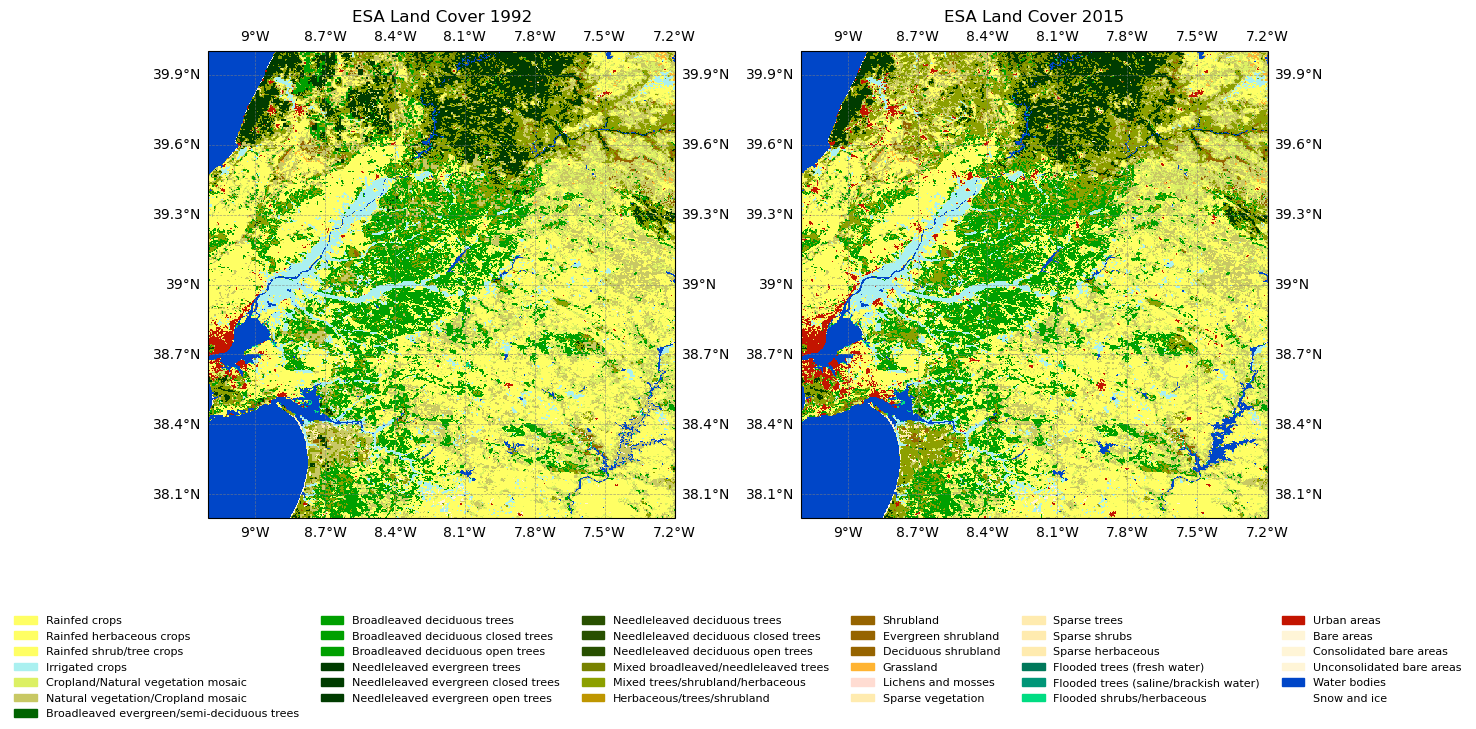

In [13]:
from livingearth_dictionary import esa_cci_lc_colours, esa_cci_lc_labels

start_year = int(start_date)
end_year = int(end_date)

year_range = range(start_year, end_year + 1)

# Only take first and last year
years_to_plot = [year_range[0], year_range[-1]]

class_ids = sorted(esa_cci_lc_labels.keys())
cmap = ListedColormap(esa_cci_lc_colours)
norm = BoundaryNorm(class_ids + [max(class_ids) + 1], ncolors=cmap.N)

# Create a figure with one column per selected year
fig, axes = plt.subplots(
    nrows=1,
    ncols=len(years_to_plot),
    figsize=(6 * len(years_to_plot), 8),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Ensure axes is iterable
if len(years_to_plot) == 1:
    axes = [axes]

for ax, year in zip(axes, years_to_plot):
    print(f"Processing year {year}...")
    timestep = f"{year}-01-01"

    # Load land cover data
    lc = lc_sub["lccs_class"].sel(time=timestep, method="nearest").squeeze().compute()
    lat = lc["lat"]
    lon = lc["lon"]

    # Plot land cover
    ax.pcolormesh(lon, lat, lc.values, cmap=cmap, norm=norm, shading="auto")

    # Gridlines
    ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color="gray", alpha=0.7, linestyle="--")

    ax.set_title(f"ESA Land Cover {year}")

# Build a single legend for all subplots
legend_handles = [
    Patch(color=esa_cci_lc_colours[class_ids.index(cid)], label=esa_cci_lc_labels[cid])
    for cid in class_ids
]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=6,
    fontsize=8,
    frameon=False
)

# Adjust layout to leave space for legend
plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

In [14]:
esa_cci_deconstruction = {
    10: 111, 11: 111, 12: 111, 20: 111, 30: 111 ,            # 111: Cultivated Terrestrial Vegetation (CTV)                       
    40: 112, 50: 112, 60: 112,                               # 112: Natural Terrestrial Vegetation (NTV)
    61: 112, 62: 112, 70: 112, 71: 112, 72: 112,
    80: 112, 81: 112, 82: 112, 90: 112, 100: 112, 110: 112,
    120: 112, 121: 112, 122: 112, 130: 112, 140: 112,
    150: 112, 151: 112, 152: 112, 153: 112,
    160: 124, 170: 124, 180: 124,                             # 124: Natural Aquatic Vegetation (NAV)
    190: 215,                                                 # 215: Artificial Surfaces
    200: 216, 201: 216, 202: 216 ,                            # 216: Naturally bare surfaces
    210: 220, 220: 220                                        # 220: Water (artificial and natural)
}

da = lc_sub['lccs_class']

arr = da.data.compute() if hasattr(da.data, "compute") else da.values

# ------------------------------------------------------------
# Output raster
# ------------------------------------------------------------
esa_cci_deconstruction_data = np.zeros(arr.shape, dtype=np.int16)

# ------------------------------------------------------------
# Reclassify
# ------------------------------------------------------------
for k, v in esa_cci_deconstruction.items():
    esa_cci_deconstruction_data[arr == k] = v

# ------------------------------------------------------------
# Build DataArray
# ------------------------------------------------------------
esa_cci_deconstruction_data_da = xr.DataArray(
    esa_cci_deconstruction_data,
    coords=da.coords,
    dims=da.dims,
    name="Level 3"
).astype("int16")

# ------------------------------------------------------------
# Attach back
# ------------------------------------------------------------
lc_sub["Level 3"] = esa_cci_deconstruction_data_da

# ------------------------------------------------------------
# Check output
# ------------------------------------------------------------
print(np.unique(esa_cci_deconstruction_data))

[111 112 124 215 216 220]


In [15]:
from livingearth_dictionary import level3_colours, level3_labels
from matplotlib.colors import ListedColormap, BoundaryNorm
import numpy as np

classes = sorted(level3_labels.keys())

level3_cmap = ListedColormap([level3_colours[c] for c in classes])

level3_norm = BoundaryNorm(
    boundaries=classes + [classes[-1] + 1],
    ncolors=len(classes)
)

In [16]:
print(level3_colours)

{0: '#FFFFFF', 111: '#D1E133', 112: '#007A02', 123: '#4EEEE8', 124: '#02C077', 215: '#DA5C69', 216: '#F3AB69', 220: '#4D9FDC'}


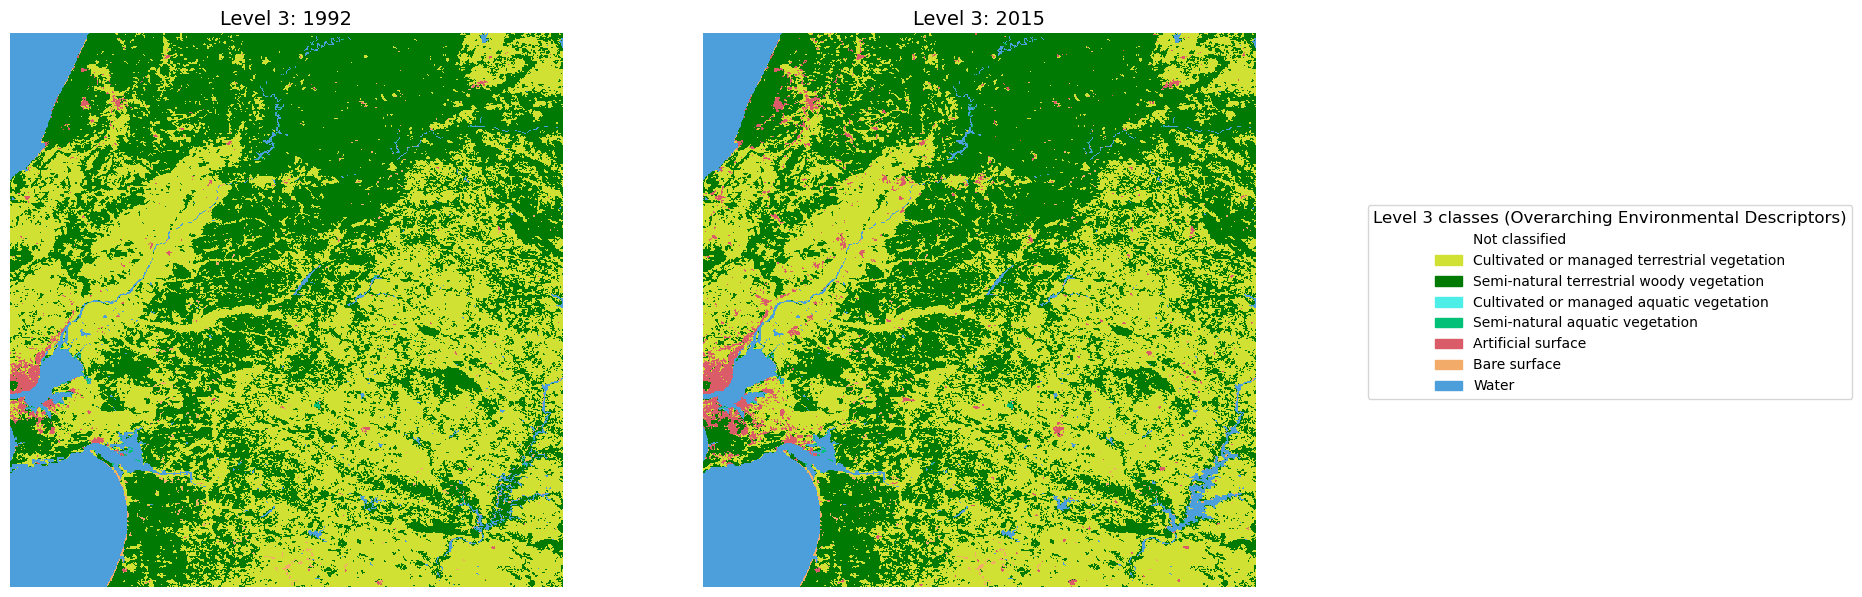

In [17]:
# Select data for start and end dates
da_start = lc_sub["Level 3"].sel(time=start_date).squeeze()
da_end   = lc_sub["Level 3"].sel(time=end_date).squeeze()

# Create figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot start date
im0 = axes[0].imshow(
    da_start.values,
    cmap=level3_cmap,
    norm=level3_norm,
    interpolation="nearest",
    extent=[
        float(da_start.lon.min()),
        float(da_start.lon.max()),
        float(da_start.lat.min()),
        float(da_start.lat.max()),
    ],
    origin="upper"
)
axes[0].set_title(f"Level 3: {start_date}", fontsize=14)
axes[0].set_axis_off()

# Plot end date
im1 = axes[1].imshow(
    da_end.values,
    cmap=level3_cmap,
    norm=level3_norm,
    interpolation="nearest",
    extent=[
        float(da_end.lon.min()),
        float(da_end.lon.max()),
        float(da_end.lat.min()),
        float(da_end.lat.max()),
    ],
    origin="upper"
)
axes[1].set_title(f"Level 3: {end_date}", fontsize=14)
axes[1].set_axis_off()

# Build a single legend for all classes
patches = [
    Patch(color=level3_colours[code], label=level3_labels[code])
    for code in sorted(level3_labels.keys())
]

fig.legend(
    handles=patches,
    bbox_to_anchor=(1.02, 0.5),
    loc='center left',
    frameon=True,
    fontsize=10,
    title='Level 3 classes (Overarching Environmental Descriptors)',
    title_fontsize=12
)

plt.subplots_adjust(right=0.78, wspace=0.05)  # adjust space between plots and legend
plt.show()

## Reconstruct lifeform

In [18]:
esa_cci_dlifeform = {
    10: 2, #"Rainfed crops",
    11: 2, #"Rainfed herbaceous crops",
    12: 1, #"Rainfed shrub/tree crops",
    20: 2, #"Irrigated crops",
    30: 2, #"Cropland/Natural vegetation mosaic",
    40: 2, #"Natural vegetation/Cropland mosaic",
    50: 1, #"Broadleaved evergreen/semi-deciduous trees",
    60: 1, #"Broadleaved deciduous trees",
    61: 1, #"Broadleaved deciduous closed trees",
    62: 1, #"Broadleaved deciduous open trees",
    70: 1, #"Needleleaved evergreen trees",
    71: 1, #"Needleleaved evergreen closed trees",
    72: 1, #"Needleleaved evergreen open trees",
    80: 1, #"Needleleaved deciduous trees",
    81: 1, #"Needleleaved deciduous closed trees",
    82: 1, #"Needleleaved deciduous open trees",
    90: 1, #"Mixed broadleaved/needleleaved trees",
    100: 1, #"Mixed trees/shrubland/herbaceous",
    110: 2, #"Herbaceous/trees/shrubland",
    120: 1, #"Shrubland",
    121: 1, #"Evergreen shrubland",
    122: 1, #"Deciduous shrubland",
    130: 2, #"Grassland",
    140: 2, #"Lichens and mosses",
    150: 2, #"Sparse vegetation",
    151: 1, #"Sparse trees",
    152: 1, #"Sparse shrubs",
    153: 2, #"Sparse herbaceous",
    160: 1, #"Flooded trees (fresh water)",
    170: 1, #"Flooded trees (saline/brackish water)",
    180: 1, #"Flooded shrubs/herbaceous",
    190: 0, #"Urban areas",
    200: 0, #"Bare areas",
    201: 0, #"Consolidated bare areas",
    202: 0, #"Unconsolidated bare areas",
    210: 0, #"Water bodies",
    220: 0, #"Snow and ice"
}

da = lc_sub['lccs_class']

arr = da.data.compute() if hasattr(da.data, "compute") else da.values

# ------------------------------------------------------------
# Output raster
# ------------------------------------------------------------
esa_cci_dlifeform_data = np.zeros(arr.shape, dtype=np.int16)

# ------------------------------------------------------------
# Reclassify
# ------------------------------------------------------------
for k, v in esa_cci_dlifeform.items():
    esa_cci_dlifeform_data[arr == k] = v

# ------------------------------------------------------------
# Build DataArray
# ------------------------------------------------------------
esa_cci_dlifeform_data_da = xr.DataArray(
    esa_cci_dlifeform_data,
    coords=da.coords,
    dims=da.dims,
    name="Lifeform"
).astype("int16")

# ------------------------------------------------------------
# Attach back
# ------------------------------------------------------------
lc_sub["Lifeform"] = esa_cci_dlifeform_data_da

# ------------------------------------------------------------
# Check output
# ------------------------------------------------------------
print(np.unique(esa_cci_dlifeform_data))

[0 1 2]


In [19]:
from livingearth_dictionary import lifeform_colours, lifeform_labels
from matplotlib.colors import ListedColormap, BoundaryNorm
import numpy as np

classes = sorted(lifeform_labels.keys())

lifeform_cmap = ListedColormap([lifeform_colours[c] for c in classes])

lifeform_norm = BoundaryNorm(
    boundaries=classes + [classes[-1] + 1],
    ncolors=len(classes)
)

In [20]:
print(lifeform_colours)

['#FFFFFF', '#21852C', '#A3CA54']


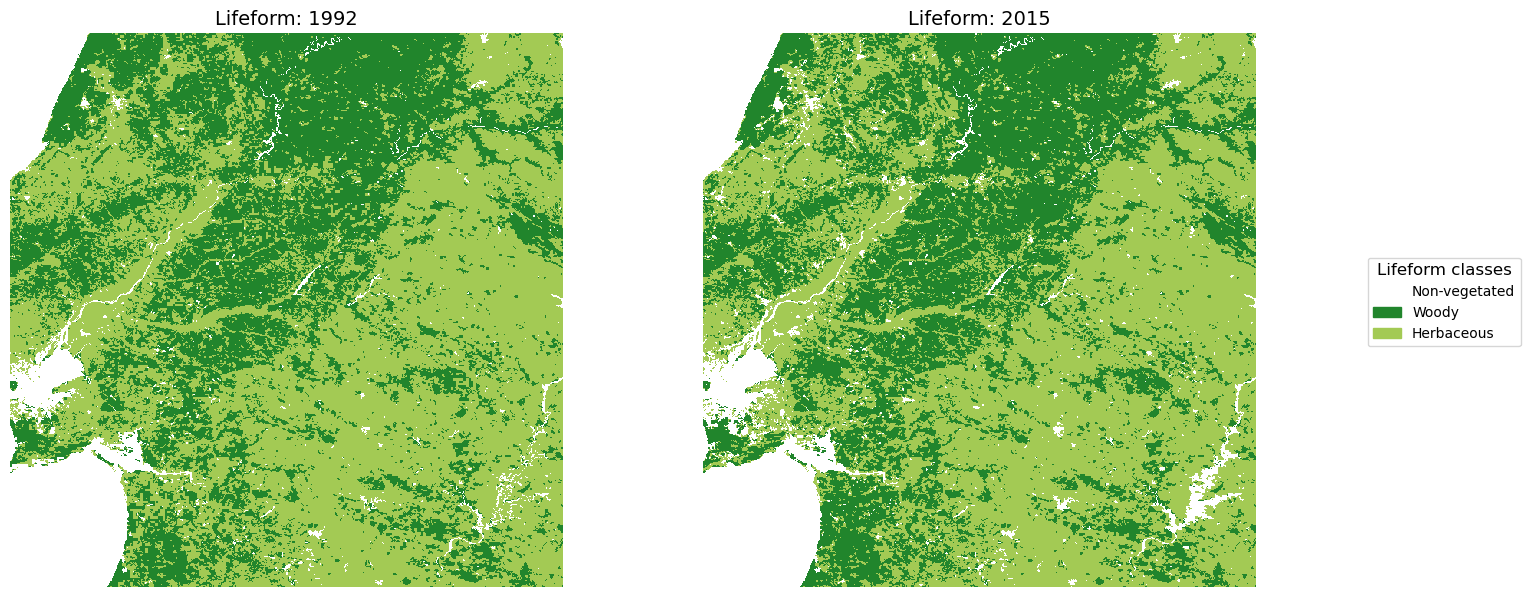

In [21]:
# Select data for start and end dates
da_start = lc_sub["Lifeform"].sel(time=start_date).squeeze()
da_end   = lc_sub["Lifeform"].sel(time=end_date).squeeze()

# Create figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot start date
im0 = axes[0].imshow(
    da_start.values,
    cmap=lifeform_cmap,
    norm=lifeform_norm,
    interpolation="nearest",
    extent=[
        float(da_start.lon.min()),
        float(da_start.lon.max()),
        float(da_start.lat.min()),
        float(da_start.lat.max()),
    ],
    origin="upper"
)
axes[0].set_title(f"Lifeform: {start_date}", fontsize=14)
axes[0].set_axis_off()

# Plot end date
im1 = axes[1].imshow(
    da_end.values,
    cmap=lifeform_cmap,
    norm=lifeform_norm,
    interpolation="nearest",
    extent=[
        float(da_end.lon.min()),
        float(da_end.lon.max()),
        float(da_end.lat.min()),
        float(da_end.lat.max()),
    ],
    origin="upper"
)
axes[1].set_title(f"Lifeform: {end_date}", fontsize=14)
axes[1].set_axis_off()

# Build a single legend for all classes
patches = [
    Patch(color=lifeform_colours[code], label=lifeform_labels[code])
    for code in sorted(lifeform_labels.keys())
]

fig.legend(
    handles=patches,
    bbox_to_anchor=(1.02, 0.5),
    loc='center left',
    frameon=True,
    fontsize=10,
    title='Lifeform classes',
    title_fontsize=12
)

plt.subplots_adjust(right=0.78, wspace=0.05)  # adjust space between plots and legend
plt.show()

## Reconstruct vegetation cover (forests)

In [22]:
esa_cci_dcover = {
    10: 10, #"Rainfed crops",
    11: 10, #"Rainfed herbaceous crops",
    12: 10, #"Rainfed shrub/tree crops",
    20: 10, #"Irrigated crops",
    30: 10, #"Cropland/Natural vegetation mosaic",
    40: 10, #"Natural vegetation/Cropland mosaic",
    50: 10, #"Broadleaved evergreen/semi-deciduous trees",
    60: 10, #"Broadleaved deciduous trees",
    61: 10, #"Broadleaved deciduous closed trees",
    62: 12, #"Broadleaved deciduous open trees",
    70: 10, #"Needleleaved evergreen trees",
    71: 10, #"Needleleaved evergreen closed trees",
    72: 12, #"Needleleaved evergreen open trees",
    80: 10, #"Needleleaved deciduous trees",
    81: 10, #"Needleleaved deciduous closed trees",
    82: 12, #"Needleleaved deciduous open trees",
    90: 10, #"Mixed broadleaved/needleleaved trees",
    100: 12, #"Mixed trees/shrubland/herbaceous",
    110: 12, #"Herbaceous/trees/shrubland",
    120: 13, #"Shrubland",
    121: 13, #"Evergreen shrubland",
    122: 13, #"Deciduous shrubland",
    130: 10, #"Grassland",
    140: 13, #"Lichens and mosses",
    150: 15, #"Sparse vegetation",
    151: 15, #"Sparse trees",
    152: 15, #"Sparse shrubs",
    153: 15, #"Sparse herbaceous",
    160: 10, #"Flooded trees (fresh water)",
    170: 10, #"Flooded trees (saline/brackish water)",
    180: 12, #"Flooded shrubs/herbaceous",
    190: 0, #"Urban areas",
    200: 0, #"Bare areas",
    201: 16, #"Consolidated bare areas",
    202: 16, #"Unconsolidated bare areas",
    210: 0, #"Water bodies",
    220: 0, #"Snow and ice"
}

da = lc_sub['lccs_class']

arr = da.data.compute() if hasattr(da.data, "compute") else da.values

# ------------------------------------------------------------
# Output raster
# ------------------------------------------------------------
esa_cci_dcover_data = np.zeros(arr.shape, dtype=np.int16)

# ------------------------------------------------------------
# Reclassify
# ------------------------------------------------------------
for k, v in esa_cci_dcover.items():
    esa_cci_dcover_data[arr == k] = v

# ------------------------------------------------------------
# Build DataArray
# ------------------------------------------------------------
esa_cci_dcover_data_da = xr.DataArray(
    esa_cci_dcover_data,
    coords=da.coords,
    dims=da.dims,
    name="Cover"
).astype("int16")

# ------------------------------------------------------------
# Attach back
# ------------------------------------------------------------
lc_sub["Cover"] = esa_cci_dcover_data_da

# ------------------------------------------------------------
# Check output
# ------------------------------------------------------------
datavalues = (np.unique(esa_cci_dcover_data))
print(datavalues)

[ 0 10 12 13 15 16]


In [23]:
# Generate colours and labels
from livingearth_dictionary import cover_colours, cover_labels

data_values = np.unique(esa_cci_dcover_data)
cover_color_dict = {cls: cover_colours[cls] for cls in data_values if cls in cover_colours}
classes_present = sorted(cover_color_dict.keys())
cover_cmap = ListedColormap([cover_color_dict[c] for c in classes_present])
cover_norm = BoundaryNorm(
    boundaries=classes_present + [classes_present[-1] + 1],
    ncolors=len(classes_present)
)

In [24]:
# Only use classes present in this subset
data_values = np.unique(esa_cci_dcover_data)
print("Values present:", data_values)

# Only keep colors for values present in the dataset
classes_present = sorted([v for v in data_values if v in cover_colours])
colors_present = [cover_colours[v] for v in classes_present]

# Create ListedColormap
cover_cmap = ListedColormap(colors_present)

# Create a BoundaryNorm that maps data values to colors
# Boundaries must be set such that each integer value is centered in a bin
boundaries = [v - 0.5 for v in classes_present] + [classes_present[-1] + 0.5]
cover_norm = BoundaryNorm(boundaries, ncolors=len(classes_present))

Values present: [ 0 10 12 13 15 16]


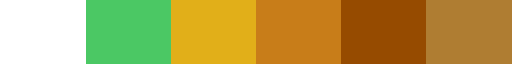

In [25]:
cover_cmap

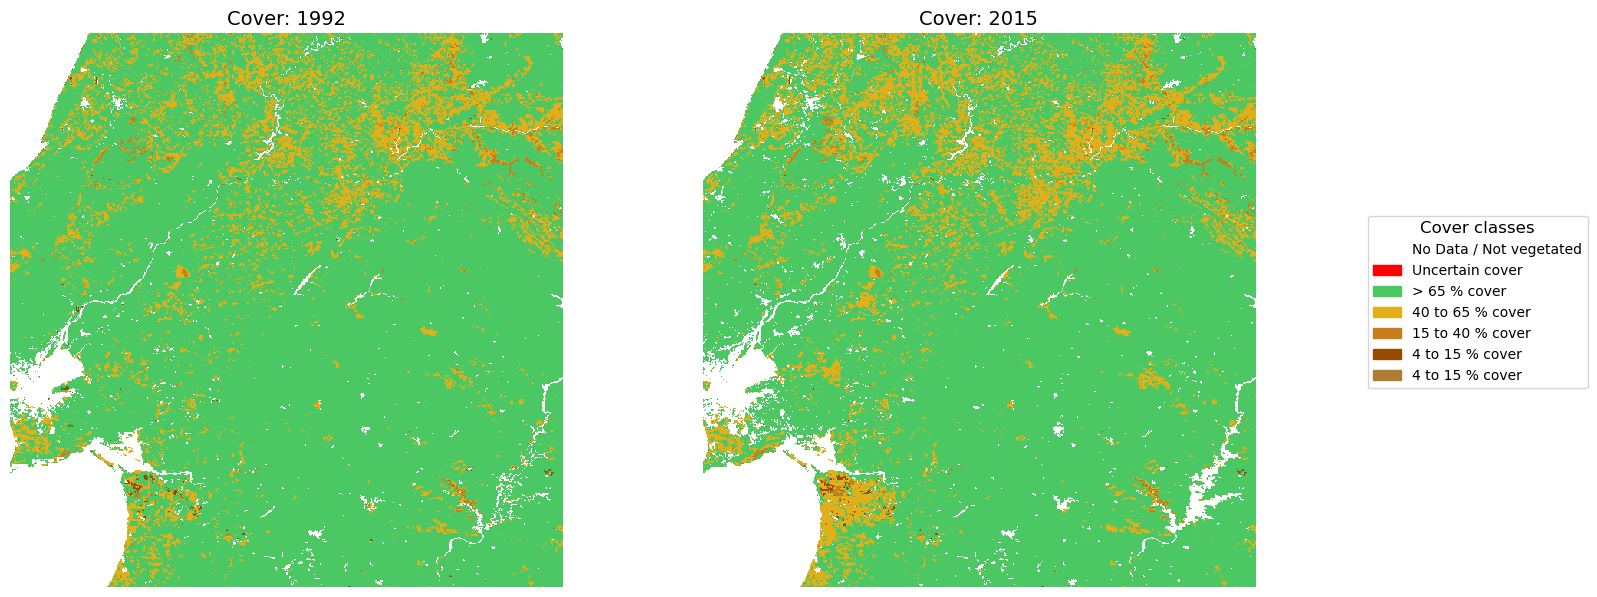

In [26]:
# Select data for start and end dates
da_start = lc_sub["Cover"].sel(time=start_date).squeeze()
da_end   = lc_sub["Cover"].sel(time=end_date).squeeze()

# Create figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot start date
im0 = axes[0].imshow(
    da_start.values,
    cmap=cover_cmap,
    norm=cover_norm,
    interpolation="nearest",
    extent=[
        float(da_start.lon.min()),
        float(da_start.lon.max()),
        float(da_start.lat.min()),
        float(da_start.lat.max()),
    ],
    origin="upper"
)
axes[0].set_title(f"Cover: {start_date}", fontsize=14)
axes[0].set_axis_off()

# Plot end date
im1 = axes[1].imshow(
    da_end.values,
    cmap=cover_cmap,
    norm=cover_norm,
    interpolation="nearest",
    extent=[
        float(da_end.lon.min()),
        float(da_end.lon.max()),
        float(da_end.lat.min()),
        float(da_end.lat.max()),
    ],
    origin="upper"
)
axes[1].set_title(f"Cover: {end_date}", fontsize=14)
axes[1].set_axis_off()

# Build a single legend for all classes
patches = [
    Patch(color=cover_colours[code], label=cover_labels[code])
    for code in sorted(cover_labels.keys())
]

fig.legend(
    handles=patches,
    bbox_to_anchor=(1.02, 0.5),
    loc='center left',
    frameon=True,
    fontsize=10,
    title='Cover classes',
    title_fontsize=12
)

plt.subplots_adjust(right=0.78, wspace=0.05)  # adjust space between plots and legend
plt.show()

In [27]:
unique_vals = np.unique(da_start)  # find unique values
print(unique_vals)                 # print them

[ 0 10 12 13 15 16]


## Observed change
The observed change considers conversions (i.e., changes in extent of the Level 3 classes) and modifications (i.e., the level 3 class remains the same but there are changes in categorical (e.g., lifeform) or continuous (e.g., water hydroperiod) environmental descriptors).

### Level 3 change maps 

The first step towards developing a globally relevant and standardized taxonomy and framework for consistently describing land cover change was to establish the transition matrix between observed broad land cover classes (i.e., OEDs).  This stage was developed (and is illustrated) using the FAO LCCS given the dichotomous and then hierarchical modular structure of this taxonomy.  Between-class transitions and within-class changes can be identified by comparing these OEDs (i.e., the FAO LCCS Level 3 classes; 8 in total) between any two time-separated periods (i.e., T1 and T2), leading to 64 potential change categories; 56 on the off-diagonals and 8 on the on-diagonals.  

In the following steps, you will compare the earliest and latest Level 3 layers in selected time-series.

In [28]:
unique_values = np.unique(lc_sub["Level 3"].sel(time=start_date, method='nearest').values)
print(unique_values)
unique_values = np.unique(lc_sub["Level 3"].sel(time=end_date, method='nearest').values)
print(unique_values)

[111 112 124 215 216 220]
[111 112 124 215 216 220]


## Gains in land cover

In [29]:
# Select start and end dates for comparison (change to int32 to ensure we can hold number of 6 digits)
start = lc_sub["Level 3"].sel(time=start_date, method='nearest').astype(np.int64).drop_vars("time")
end   = lc_sub["Level 3"].sel(time=end_date, method='nearest').astype(np.int64).drop_vars("time")
ignore_no_change = True
change_vals = (start * 1000 + end)  # 1000 to keep 6-digit codes intact
if ignore_no_change:
    change_vals = np.where(start == end, 0, change_vals)
display(np.unique(change_vals))

array([     0, 111112, 111215, 111220, 112111, 112124, 112215, 112216,
       112220, 124112, 124215, 124220, 216112, 216215, 216220, 220111,
       220112, 220124, 220215, 220216])

In [30]:
# #level3 = lc_sub["Level 3"].sel(time=start_date, method='nearest').drop_vars("time")

# obs_gain_l3_T1T2 = xr.DataArray(
#     data=change_vals,
#     lc_sub["Level 3"]
#     coords=level3.coords,
#     dims=level3.dims,
#     name="observed change",
#     attrs=level3.attrs,
#     fastpath=False,
# )

In [31]:
da_2d = lc_sub.isel(time=0)
obs_gain_l3_T1T2 = xr.DataArray(
    data=change_vals,
    coords=da_2d.coords,
    dims=da_2d.dims,
    name="observed change",
    attrs=da_2d.attrs,
    fastpath=False,
)

In [32]:
obs_gain_l3 = obs_gain_l3_T1T2.to_dataset(name="l3_T1T2")
del obs_gain_l3_T1T2

In [33]:
obs_gain_l3.l3_T1T2
unique_vals = np.unique(obs_gain_l3.l3_T1T2.values)

print(unique_vals)

[     0 111112 111215 111220 112111 112124 112215 112216 112220 124112
 124215 124220 216112 216215 216220 220111 220112 220124 220215 220216]


In [34]:
from livingearth_dictionary import level3_gainloss_colours, level3_gainloss_labels

# Sorted classes
classes = sorted(level3_gainloss_labels.keys())

# Map class IDs to colors
level3_gainloss_colours_dict = {cid: color for cid, color in zip(classes, level3_gainloss_colours)}

# Create colormap
level3_gainloss_cmap = ListedColormap([level3_gainloss_colours_dict[c] for c in classes])

# Create norm
level3_gainloss_norm = BoundaryNorm(
    boundaries=classes + [classes[-1] + 1],
    ncolors=level3_gainloss_cmap.N
)

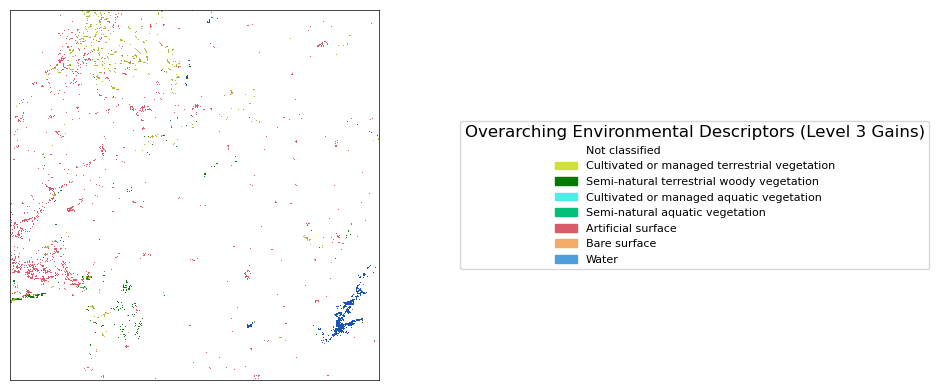

In [35]:
# --- Ensure dataset has CRS and reproject to EPSG:4326 ---
obs_gain_l3 = obs_gain_l3.rio.write_crs("EPSG:3577")

# Plot your reprojected data (square figure)
fig, ax = plt.subplots(figsize=(5, 4))
ax.set_aspect('equal')
main_pos = ax.get_position()

c = obs_gain_l3.l3_T1T2.plot(
    ax=ax,
    cmap=level3_gainloss_cmap,
    norm=level3_gainloss_norm,
    add_colorbar=False
)

# Remove tick marks and coordinate labels
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")

# Optional figure label
fig.text(
    main_pos.x0,
    main_pos.y1 + 0.02,
    "",
    fontsize=20,
    ha="left",
    va="bottom"
)


# Add black box around map
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(0.5)

# Title
ax.set_title("", fontsize=16)

patches = [
    Patch(color=level3_colours[code], label=level3_labels[code])
    for code in sorted(level3_labels.keys())
]

fig.legend(
    handles=patches,
    bbox_to_anchor=(1.02, 0.5),
    loc='center left',
    frameon=True,
    fontsize=8,
    title='Overarching Environmental Descriptors (Level 3 Gains)',
    title_fontsize=12
)

plt.tight_layout()
plt.show()

## Losses in land cover

In [36]:
# Select start and end dates for comparison (change to int32 to ensure we can hold number of 6 digits)
start = lc_sub["Level 3"].sel(time=start_date, method='nearest').astype(np.int64).drop_vars("time")
end   = lc_sub["Level 3"].sel(time=end_date, method='nearest').astype(np.int64).drop_vars("time")
ignore_no_change = True
change_vals = (end * 1000 + start)  # 1000 to keep 6-digit codes intact
if ignore_no_change:
    change_vals = np.where(start == end, 0, change_vals)
display(np.unique(change_vals))

array([     0, 111112, 111220, 112111, 112124, 112216, 112220, 124112,
       124220, 215111, 215112, 215124, 215216, 215220, 216112, 216220,
       220111, 220112, 220124, 220216])

In [37]:
level3 = lc_sub["Level 3"].sel(time=start_date, method='nearest').drop_vars("time")
# Create a new Xarray.DataArray
obs_loss_l3_T1T2 = xr.DataArray(
    data=change_vals,
    coords=da_2d.coords,
    dims=da_2d.dims,
    name="observed gains",
    attrs=da_2d.attrs,
    fastpath=False,
)

In [38]:
obs_loss_l3 = obs_loss_l3_T1T2.to_dataset(name="l3_T1T2")
del obs_loss_l3_T1T2

In [39]:
obs_loss_l3.l3_T1T2
unique_vals = np.unique(obs_loss_l3.l3_T1T2.values)

print(unique_vals)

[     0 111112 111220 112111 112124 112216 112220 124112 124220 215111
 215112 215124 215216 215220 216112 216220 220111 220112 220124 220216]


In [40]:
from livingearth_dictionary import level3_gainloss_colours, level3_gainloss_labels

# Sorted classes
classes = sorted(level3_gainloss_labels.keys())

# Map class IDs to colors
level3_gainloss_colours_dict = {cid: color for cid, color in zip(classes, level3_gainloss_colours)}

# Create colormap
level3_gainloss_cmap = ListedColormap([level3_gainloss_colours_dict[c] for c in classes])

# Create norm
level3_gainloss_norm = BoundaryNorm(
    boundaries=classes + [classes[-1] + 1],
    ncolors=level3_gainloss_cmap.N
)

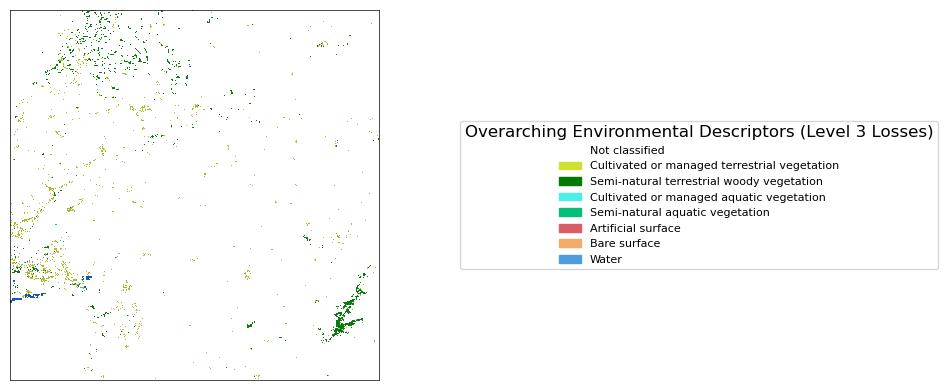

In [41]:
# --- Ensure dataset has CRS and reproject to EPSG:4326 ---
obs_loss_l3 = obs_loss_l3.rio.write_crs("EPSG:3577")

# Plot your reprojected data (square figure)
fig, ax = plt.subplots(figsize=(5, 4))
ax.set_aspect('equal')
main_pos = ax.get_position()

c = obs_loss_l3.l3_T1T2.plot(
    ax=ax,
    cmap=level3_gainloss_cmap,
    norm=level3_gainloss_norm,
    add_colorbar=False
)

# Remove tick marks and coordinate labels
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")

# Optional figure label
fig.text(
    main_pos.x0,
    main_pos.y1 + 0.02,
    "",
    fontsize=20,
    ha="left",
    va="bottom"
)


# Add black box around map
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(0.5)

# Title
ax.set_title("", fontsize=16)

patches = [
    Patch(color=level3_colours[code], label=level3_labels[code])
    for code in sorted(level3_labels.keys())
]

fig.legend(
    handles=patches,
    bbox_to_anchor=(1.02, 0.5),
    loc='center left',
    frameon=True,
    fontsize=8,
    title='Overarching Environmental Descriptors (Level 3 Losses)',
    title_fontsize=12
)

plt.tight_layout()
plt.show()

### NO CHANGE

In [42]:
start = lc_sub["Level 3"].sel(time=start_date, method='nearest').astype(np.int64)
end   = lc_sub["Level 3"].sel(time=end_date, method='nearest').astype(np.int64)
ignore_no_change = True
change_vals = (start * 1000 + end)  # 1000 to keep 6-digit codes intact
if ignore_no_change:
    change_vals = np.where(start != end, 0, change_vals)
display(np.unique(change_vals))

array([     0, 111111, 112112, 124124, 215215, 216216, 220220])

In [43]:
level3 = lc_sub["Level 3"].sel(time=start_date, method='nearest').drop_vars("time")
# Create a new Xarray.DataArray
obs_no_change_l3_T1T2 = xr.DataArray(
    data=change_vals,
    coords=da_2d.coords,
    dims=da_2d.dims,
    name="no change",
    attrs=da_2d.attrs,
    fastpath=False,
)

In [44]:
obs_no_change_l3= obs_no_change_l3_T1T2.to_dataset(name="l3_T1T2")
del obs_no_change_l3_T1T2

In [45]:
obs_no_change_l3.l3_T1T2
unique_vals = np.unique(obs_no_change_l3.l3_T1T2.values)

print(unique_vals)

[     0 111111 112112 124124 215215 216216 220220]


In [46]:
# # Define a colour scheme for the Level 3 no change
# LEVEL3_NOCHANGE = {
#     0: (255, 255, 255, 255, "Change"),
#     111111: (172, 188, 45, 255, " "),
#     112112: (14, 121, 18, 255, " "),
#     123123: (0, 255, 255, 255, " "),
#     124124: (30, 191, 121, 255, " "),
#     215215: (218, 92, 105, 255, " "),
#     216216: (243, 171, 105, 255, " "),
#     220220: (77, 159, 220, 255, " ")}

In [47]:
from livingearth_dictionary import level3_nochange_colours, level3_nochange_labels

# Sorted classes
classes = sorted(level3_nochange_labels.keys())

# Map class IDs to colors
level3_nochange_colours_dict = {cid: color for cid, color in zip(classes, level3_nochange_colours)}

# Create colormap
level3_nochange_cmap = ListedColormap([level3_nochange_colours_dict[c] for c in classes])

# Create norm
level3_nochange_norm = BoundaryNorm(
    boundaries=classes + [classes[-1] + 1],
    ncolors=level3_nochange_cmap.N
)

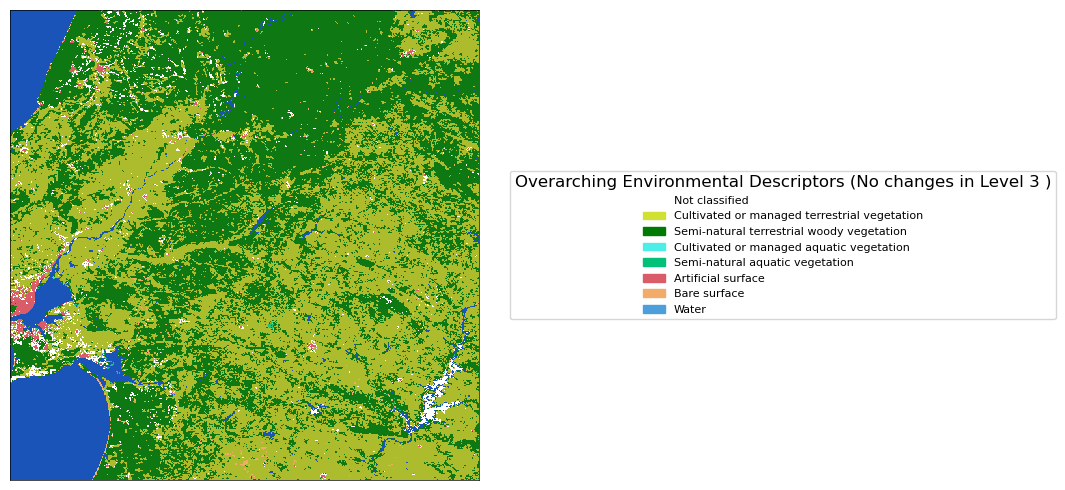

In [48]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --- Ensure dataset has CRS but DO NOT reproject ---
obs_no_change_l3 = obs_no_change_l3.rio.write_crs("EPSG:3577")

# Plot using native EPSG:3577 coordinates (square figure)
fig, ax = plt.subplots(figsize=(5, 5))
ax.set_aspect('equal')
main_pos = ax.get_position()

c = obs_no_change_l3.l3_T1T2.plot(
    ax=ax,
    cmap=level3_nochange_cmap,
    norm=level3_nochange_norm,
    add_colorbar=False
)

# Remove tick marks and coordinate labels
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")

# Optional figure label
fig.text(
    main_pos.x0,
    main_pos.y1 + 0.02,
    " ",
    fontsize=20,
    ha="left",
    va="bottom"
)

# Add thin black border
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(0.5)

# Title (currently blank to match your example)
ax.set_title("", fontsize=16)

patches = [
    Patch(color=level3_colours[code], label=level3_labels[code])
    for code in sorted(level3_labels.keys())
]

fig.legend(
    handles=patches,
    bbox_to_anchor=(1.02, 0.5),
    loc='center left',
    frameon=True,
    fontsize=8,
    title='Overarching Environmental Descriptors (No changes in Level 3 )',
    title_fontsize=12
)

plt.tight_layout()
plt.show()

### Lifeform changes
The following generates maps of change by concatenating the values for lifeform identified in each of the two time-steps (e.g., 1988 and 2024), noting that some areas can go from no vegetation to woody or herbaceous (i.e., 01 or 02), from these categories to no vegetation (i.e., 10 or 20) or remain as non-vegetated (0 to 0).  The lifeform can remain the same (i.e., 11 or 22) or change (i.e. 12 or 21).  This is summarised in the table below.

| Value |  LCCS Description         |
|-------|-------------------------|
| 11     |Remains as woody|
| 22     |Remains as herbaceous |
| 12     |Woody to herbaceous|
| 21     |Herbaceous to woody|
| 01     |Not vegetated to woody|
| 02     |Not vegetated to herbaceous |
| 10     |Woody to not vegetated|
| 20     |Herbaceous to not vegetated |

The following generates maps of these modifications, which represent a change in type.

In [49]:
lc_sub = lc_sub.rename({v: v.strip() for v in lc_sub.data_vars})
start = lc_sub["Lifeform"].sel(time=start_date, method='nearest').astype(np.int8)
end   = lc_sub["Lifeform"].sel(time=end_date, method='nearest').astype(np.int8)
ignore_no_change = False
change_vals = ((start * 10) + end)
if ignore_no_change:
    change_vals = np.where(start == end, 0, change_vals)
display(np.unique(change_vals))

array([ 0,  1,  2, 10, 11, 12, 20, 21, 22], dtype=int8)

In [50]:
print(list(lc_sub.data_vars))

['change_count', 'current_pixel_state', 'lccs_class', 'observation_count', 'processed_flag', 'Level 3', 'Lifeform', 'Cover']


In [51]:
obs_change_lf_modification = xr.DataArray(
    data=change_vals,
    coords=da_2d.coords,
    dims=da_2d.dims,
    name="lifeform change",
    attrs=da_2d.attrs,
    fastpath=False,
)

In [52]:
from livingearth_dictionary import lifeform_change_colours, lifeform_change_labels
classes = sorted(lifeform_change_labels.keys())
lifeform_change_colours_dict = {cid: color for cid, color in zip(classes, lifeform_change_colours)}
lifeform_change_cmap = ListedColormap([lifeform_change_colours_dict[c] for c in classes])
lifeform_change_norm = BoundaryNorm(
    boundaries=classes + [classes[-1] + 1],
    ncolors=lifeform_change_cmap.N
)

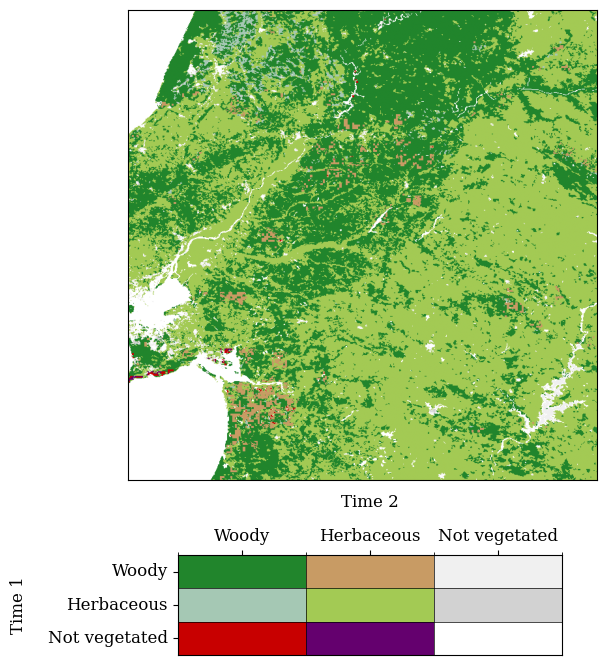

In [53]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm, to_rgb

# -----------------------------
# Font settings
# -----------------------------
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times", "DejaVu Serif"]

# -----------------------------
# Classes for the legend (Time 1 vs Time 2)
# -----------------------------
classes = ("Not vegetated", "Herbaceous", "Woody")
n_classes = len(classes)

# -----------------------------
# Map row,col in 3x3 legend to lifeform_change class IDs
# -----------------------------
code_map = {
    (0,0): 11, (0,1): 21, (0,2): 20,
    (1,0): 12, (1,1): 22, (1,2): 10,
    (2,0): 1,  (2,1): 2,  (2,2): 0,
}

# -----------------------------
# Convert hex colors to RGB floats
# -----------------------------
lifeform_change_colors_rgb = [to_rgb(c) for c in lifeform_change_colours]

# Create colormap and norm
lifeform_change_cmap = ListedColormap(lifeform_change_colors_rgb)
lifeform_classes = sorted(lifeform_change_labels.keys())
lifeform_change_norm = BoundaryNorm(
    boundaries=lifeform_classes + [lifeform_classes[-1]+1],
    ncolors=lifeform_change_cmap.N
)

# Build mapping from class ID → colormap index
code_to_cmap_idx = {cid: i for i, cid in enumerate(lifeform_classes)}

# -----------------------------
# Build legend image (3x3)
# -----------------------------
legend_img = np.zeros((n_classes, n_classes, 3))
for i in range(n_classes):
    for j in range(n_classes):
        code = code_map[(i,j)]
        idx = code_to_cmap_idx[code]
        rgb = np.array(lifeform_change_cmap.colors[idx])  # RGB floats
        legend_img[i, j] = rgb

# -----------------------------
# Main figure: LIFEFORM change map
# -----------------------------
fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(
    obs_change_lf_modification.values,  # Your DataArray of lifeform change
    cmap=lifeform_change_cmap,
    norm=lifeform_change_norm
)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("", fontsize=16)

main_pos = ax.get_position()

# Optional figure label
fig.text(
    main_pos.x0,
    main_pos.y1 + 0.02,
    "",
    fontsize=20,
    ha="left",
    va="bottom"
)

# -----------------------------
# Legend axis below map
# -----------------------------
scale_factor = 0.8
legend_height = 0.25 * scale_factor
legend_spacing = 0.08
legend_bottom = main_pos.y0 - legend_height - legend_spacing - 0.15

legend_ax = fig.add_axes([
    main_pos.x0,
    legend_bottom,
    main_pos.width,
    legend_height
])

# Display legend image
legend_ax.imshow(
    legend_img,
    aspect='auto',
    extent=[0, n_classes, 0, n_classes * scale_factor]
)

# Tick positions
tick_pos = np.arange(n_classes) + 0.5
legend_ax.set_xticks(tick_pos)
legend_ax.set_yticks((np.arange(n_classes) + 0.5) * scale_factor)

# Legend axis labels
legend_ax.xaxis.set_label_position('top')
legend_ax.xaxis.tick_top()
legend_ax.set_xticklabels(classes[::-1], rotation=0, ha="center", fontsize=12)
legend_ax.set_yticklabels(classes, rotation=0, va="center", fontsize=12)

# Axis labels with padding
legend_ax.set_xlabel("Time 2", fontsize=12, labelpad=15)
legend_ax.set_ylabel("Time 1", fontsize=12, labelpad=15)

# Minor grid lines
legend_ax.set_xticks(np.arange(n_classes+1), minor=True)
legend_ax.set_yticks(np.arange(n_classes+1) * scale_factor, minor=True)
legend_ax.grid(which="minor", color="black", linestyle='-', linewidth=0.5)
legend_ax.tick_params(which="minor", bottom=False, left=False)

plt.show()

In [54]:
start = lc_sub["Cover"].sel(time=start_date, method='nearest').astype(np.int64)
end   = lc_sub["Cover"].sel(time=end_date, method='nearest').astype(np.int64)
ignore_no_change = False
change_vals = (start * 100) + end
if ignore_no_change:
    change_vals = np.where(start == end, 0, change_vals)
display(np.unique(change_vals))

array([   0,   10,   12,   13,   15,   16, 1000, 1010, 1012, 1013, 1015,
       1200, 1210, 1212, 1213, 1215, 1300, 1310, 1312, 1313, 1500, 1510,
       1512, 1515, 1600, 1616])

In [55]:
obs_change_vcov_modification = xr.DataArray(
    data=change_vals,
    coords=da_2d.coords,
    dims=da_2d.dims,
    name="cover change",
    attrs=da_2d.attrs,
    fastpath=False,
)

In [56]:
from livingearth_dictionary import cover_change_colours, cover_change_labels
classes = sorted(cover_change_labels.keys())
cover_change_colours_dict = {cid: color for cid, color in zip(classes, cover_change_colours)}
cover_change_cmap = ListedColormap([cover_change_colours_dict[c] for c in classes])
cover_change_norm = BoundaryNorm(
    boundaries=classes + [classes[-1] + 1],
    ncolors=cover_change_cmap.N
)    

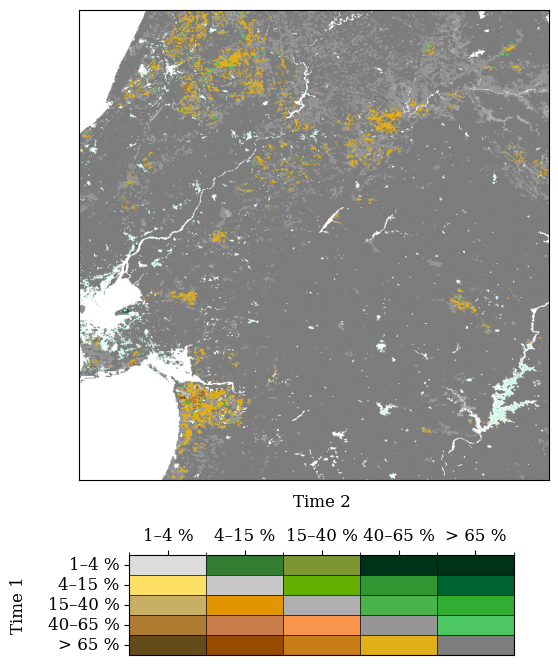

In [57]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm, to_rgb

# -----------------------------
# Font settings
# -----------------------------
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times", "DejaVu Serif"]

# -----------------------------
# Classes for the legend (Time 1 vs Time 2)
# -----------------------------
classes = ["> 65 %", "40–65 %", "15–40 %", "4–15 %", "1–4 %"]
n_classes = len(classes)

# -----------------------------
# Map row,col in 3x3 legend to lifeform_change class IDs
# -----------------------------
code_map = {
    (0,0):1616, (0,1):1612, (0,2):1613, (0,3):1610, (0,4):1610,
    (1,0):1516, (1,1):1515, (1,2):1513, (1,3):1512, (1,4):1510,
    (2,0):1316, (2,1):1315, (2,2):1313, (2,3):1312, (2,4):1310,
    (3,0):1216, (3,1):1215, (3,2):1213, (3,3):1212, (3,4):1210,
    (4,0):1016, (4,1):1015, (4,2):1013, (4,3):1012, (4,4):1010,
}

# -----------------------------
# Convert hex colors to RGB floats
# -----------------------------
cover_change_colors_rgb = [to_rgb(c) for c in cover_change_colours]

# Create colormap and norm
cover_change_cmap = ListedColormap(cover_change_colors_rgb)
cover_classes = sorted(cover_change_labels.keys())
cover_change_norm = BoundaryNorm(
    boundaries=cover_classes + [cover_classes[-1]+1],
    ncolors=cover_change_cmap.N
)

# Build mapping from class ID → colormap index
code_to_cmap_idx = {cid: i for i, cid in enumerate(cover_classes)}

# -----------------------------
# Build legend image (3x3)
# -----------------------------
legend_img = np.zeros((n_classes, n_classes, 3))
for i in range(n_classes):
    for j in range(n_classes):
        code = code_map[(i,j)]
        idx = code_to_cmap_idx[code]
        rgb = np.array(cover_change_cmap.colors[idx])  # RGB floats
        legend_img[i, j] = rgb

# -----------------------------
# Main figure: COVER change map
# -----------------------------
fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(
    obs_change_vcov_modification.values,  # Your DataArray of lifeform change
    cmap=cover_change_cmap,
    norm=cover_change_norm
)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("", fontsize=16)

main_pos = ax.get_position()

# Optional figure label
fig.text(
    main_pos.x0,
    main_pos.y1 + 0.02,
    "",
    fontsize=20,
    ha="left",
    va="bottom"
)

# -----------------------------
# Legend axis below map
# -----------------------------
scale_factor = 0.8
legend_height = 0.25 * scale_factor
legend_spacing = 0.08
legend_bottom = main_pos.y0 - legend_height - legend_spacing - 0.15

legend_ax = fig.add_axes([
    main_pos.x0,
    legend_bottom,
    main_pos.width,
    legend_height
])

# Display legend image
legend_ax.imshow(
    legend_img,
    aspect='auto',
    extent=[0, n_classes, 0, n_classes * scale_factor]
)

# Tick positions
tick_pos = np.arange(n_classes) + 0.5
legend_ax.set_xticks(tick_pos)
legend_ax.set_yticks((np.arange(n_classes) + 0.5) * scale_factor)

# Legend axis labels
legend_ax.xaxis.set_label_position('top')
legend_ax.xaxis.tick_top()
legend_ax.set_xticklabels(classes[::-1], rotation=0, ha="center", fontsize=12)
legend_ax.set_yticklabels(classes, rotation=0, va="center", fontsize=12)

# Axis labels with padding
legend_ax.set_xlabel("Time 2", fontsize=12, labelpad=15)
legend_ax.set_ylabel("Time 1", fontsize=12, labelpad=15)

# Minor grid lines
legend_ax.set_xticks(np.arange(n_classes+1), minor=True)
legend_ax.set_yticks(np.arange(n_classes+1) * scale_factor, minor=True)
legend_ax.grid(which="minor", color="black", linestyle='-', linewidth=0.5)
legend_ax.tick_params(which="minor", bottom=False, left=False)

plt.show()

## The Global Change Taxonomy and Evidence-Based Change Framework
### Evidence for impacts
Evidence for different impacts is gathered through temporal comparison (e.g., days, decades apart) of land cover classes constructed and described from Environmental Descriptors (EDs; state indicators) with pre-defined measurement units (e.g., m, %) or categories (e.g., species type) and, more specifically, their concatenated codes (e.g., 12 indicating a change from a woody (1) to a herbaceous (2) lifeform. 

For the 77 impacts listed in the Global Change Taxonomy, this evidence has been reviewed and collated within the file ***Impacts and pressures.xlsx*** located within the directory ***gct***.  

### Evidence for pressures
Evidence for abiotic, biotic or human-induced pressures can come from a range of sources.    

<img align="centre" src="./illustrations/EvidencePressures.jpg">

For the 144 impacts, evidence can come from a range of sources and the file ***Impacts and pressures.xlsx*** can be modified based on what is available.  Normally, a pressure (such as a fire) is indicated by its presence (e.g. 1) or otherwise (0).

The following cell allows you to select one of the 77 impacts and associates this selection with a range of pressures that may be causative. 

In [58]:
print(np.unique(obs_gain_l3["l3_T1T2"]))

[     0 111112 111215 111220 112111 112124 112215 112216 112220 124112
 124215 124220 216112 216215 216220 220111 220112 220124 220215 220216]


In [59]:
print(np.unique(obs_loss_l3["l3_T1T2"]))

[     0 111112 111220 112111 112124 112216 112220 124112 124220 215111
 215112 215124 215216 215220 216112 216220 220111 220112 220124 220216]


In [60]:
print(np.unique(obs_no_change_l3["l3_T1T2"]))

[     0 111111 112112 124124 215215 216216 220220]


In [61]:
# ==========================================================
# IMPORTS
# ==========================================================

import geopandas as gpd
import pandas as pd
import numpy as np
import xarray as xr

import matplotlib.pyplot as plt
import ipywidgets as widgets

from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap, BoundaryNorm

from IPython.display import (
    display,
    HTML,
    clear_output
)

from livingearth_dictionary import (
    impact_colours,
    impact_labels
)

# ==========================================================
# LOAD EXCEL
# ==========================================================

file_path = 'Impacts.xlsx'

df = pd.read_excel(
    file_path,
    sheet_name='Australia'
)

df['Impact_ID'] = (
    df['Impact_ID']
    .fillna(0)
    .astype(int)
)

df['Pressure_ID'] = (
    df['Pressure_ID']
    .fillna(0)
    .astype(int)
)

# ==========================================================
# CREATE LOOKUP FOR IMPACTS
# ==========================================================

impact_to_pressures = df.groupby(
    ['Impacts', 'Impact_ID']
)[['Pressures', 'Pressure_ID']].apply(
    lambda x: [
        f"{row['Pressures']} ({row['Pressure_ID']})"
        for _, row in x.iterrows()
    ]
).to_dict()

# ==========================================================
# COLOURMAPS
# ==========================================================

codes_ordered = list(impact_labels.keys())

impact_cmap = ListedColormap([
    impact_colours[codes_ordered.index(c)]
    for c in codes_ordered
])

impact_norm = BoundaryNorm(
    boundaries=codes_ordered + [codes_ordered[-1] + 1],
    ncolors=len(codes_ordered)
)

# ==========================================================
# EXTRACT VALUES
# ==========================================================

def extract_values(row, prefix):

    cols = [
        c for c in row.index
        if c.startswith(prefix)
    ]

    values = {}

    for c in cols:

        val = row[c]

        if pd.isna(val):
            continue

        try:

            val = str(val).strip()

            if val == "" or val == "nan":
                continue

            values[c] = int(float(val))

        except:
            continue

    return values



In [62]:
# ==========================================================
# BUILD RULES
# ==========================================================

def build_rule_from_row(row):

    mod_values  = extract_values(row, 'Mod')
    con_values  = extract_values(row, 'Con')
    lf_values   = extract_values(row, 'Lf')
    vcov_values = extract_values(row, 'Cov')

    # Store evidence
    evidence = {
        "Mod": mod_values,
        "Con": con_values,
        "Lf": lf_values,
        "Cov": vcov_values
    }

    # ------------------------------------------------------

    def rule():

        base = xr.ones_like(
            obs_change_vcov_modification,
            dtype=bool
        )

        # ==================================================
        # LEVEL 3
        # ==================================================

        mod_condition = (
            obs_no_change_l3.l3_T1T2.isin(
                list(mod_values.values())
            )
            if mod_values else None
        )

        con_condition = (
            obs_gain_l3.l3_T1T2.isin(
                list(con_values.values())
            )
            if con_values else None
        )

        loss_condition = (
            obs_loss_l3.l3_T1T2.isin(
                list(con_values.values())
            )
            if con_values else None
        )

        level3_conditions = [
            c for c in [
                mod_condition,
                con_condition,
                loss_condition
            ]
            if c is not None
        ]

        if level3_conditions:

            level3_condition = level3_conditions[0]

            for cond in level3_conditions[1:]:

                level3_condition = (
                    level3_condition |
                    cond
                )

        else:

            level3_condition = base

        # ==================================================
        # LIFEFORM
        # ==================================================

        lf_condition = (
            obs_change_lf_modification.isin(
                list(lf_values.values())
            )
            if lf_values else base
        )

        # ==================================================
        # VEGETATION COVER
        # ==================================================

        vcov_condition = (
            obs_change_vcov_modification.isin(
                list(vcov_values.values())
            )
            if vcov_values else base
        )

        # ==================================================
        # FINAL CONDITION
        # ==================================================

        condition = (
            level3_condition &
            lf_condition &
            vcov_condition
        )

        return condition

    # ------------------------------------------------------

    return rule, evidence

# ==========================================================
# BUILD ALL IMPACT RULES
# ==========================================================

impact_rules = {}
impact_evidence = {}

for impact_id in df['Impact_ID'].unique():

    row = df[
        df['Impact_ID'] == impact_id
    ].iloc[0]

    rule, evidence = build_rule_from_row(row)

    impact_rules[impact_id] = rule
    impact_evidence[impact_id] = evidence

# ==========================================================
# CREATE IMPACT LAYER
# ==========================================================

def create_impact_layer(
    impact_id,
    pressure_id,
    condition,
    coords_source,
    name
):

    data = np.where(
        condition,
        impact_id,
        0
    )

    return xr.DataArray(
        data=data,
        coords=coords_source.coords,
        dims=coords_source.dims,
        name=name,
        attrs={
            "Impact_ID": impact_id,
            "Pressure_ID": pressure_id
        }
    ).to_dataset(name=name)

# ==========================================================
# CREATE LEGEND
# ==========================================================

def create_selected_legend(selected_impacts):

    legend_handles = []

    impact_lookup = {}

    for impact_id, label in impact_labels.items():

        colour = impact_colours[impact_id]

        impact_lookup[impact_id] = (
            colour,
            label
        )

    for impact_name, impact_id in selected_impacts:

        if impact_id not in impact_lookup:
            continue

        colour, label = impact_lookup[impact_id]

        patch = Patch(
            facecolor=colour,
            edgecolor='black',
            label=f"{impact_id}: {label}"
        )

        legend_handles.append(patch)

    return legend_handles

# ==========================================================
# CHECKBOXES
# ==========================================================

impact_checkboxes = {}

for impact_name, impact_id in impact_to_pressures.keys():

    label = f"{impact_name} ({impact_id})"

    impact_checkboxes[label] = widgets.Checkbox(
        value=False,
        description=label,
        indent=False,
        layout=widgets.Layout(width='700px')
    )

# ==========================================================
# SELECT ALL
# ==========================================================

select_all = widgets.Checkbox(
    value=False,
    description='Select All'
)

def toggle_all(change):

    for cb in impact_checkboxes.values():

        cb.value = change['new']

select_all.observe(
    toggle_all,
    names='value'
)

# ==========================================================
# BUTTONS
# ==========================================================

run_button = widgets.Button(
    description='Run Selected Impacts',
    button_style='success'
)

sum_button = widgets.Button(
    description='Create Summed Impacts',
    button_style='info'
)

output = widgets.Output()

# ==========================================================
# RUN INDIVIDUAL IMPACTS
# ==========================================================

def run(button):

    with output:

        clear_output()

        selected = [
            cb.description
            for cb in impact_checkboxes.values()
            if cb.value
        ]

        if not selected:

            print("No impacts selected")
            return

        results = []

        for impact_text in selected:

            impact_name, impact_id = impact_text.rsplit(
                ' (',
                1
            )

            impact_id = int(
                impact_id.rstrip(')')
            )

            print(f"Running {impact_name}")

            evidence = impact_evidence[impact_id]

            # ==========================================
            # DEBUGGING
            # ==========================================

            print("Evidence used:")
            print(f"  Mod: {evidence['Mod']}")
            print(f"  Con: {evidence['Con']}")
            print(f"  Lf : {evidence['Lf']}")
            print(f"  Cov: {evidence['Cov']}")

            print(
                "Unique VCOV raster values:",
                np.unique(
                    obs_change_vcov_modification.values
                )
            )

            print("-" * 40)

            # ==========================================

            rule = impact_rules[impact_id]

            condition = rule()

            ds = create_impact_layer(
                impact_id=impact_id,
                pressure_id=0,
                condition=condition,
                coords_source=obs_change_vcov_modification,
                name=impact_name.replace(" ", "_")
            )

            globals()[
                impact_name.replace(" ", "_")
            ] = ds

            results.append(
                (impact_name, ds)
            )

        # ==================================================
        # PLOTTING
        # ==================================================

        n = len(results)

        cols = 3

        rows = int(
            np.ceil(n / cols)
        )

        fig, axes = plt.subplots(
            rows,
            cols,
            figsize=(6 * cols, 6 * rows)
        )

        axes = np.array(axes).reshape(-1)

        for ax, (impact_name, ds) in zip(
            axes,
            results
        ):

            var = list(ds.data_vars)[0]

            da = ds[var]

            ax.imshow(
                da.values,
                cmap=impact_cmap,
                norm=impact_norm
            )

            ax.set_title(impact_name)

            ax.axis("off")

        for ax in axes[len(results):]:

            ax.axis("off")

        plt.tight_layout()

        plt.show()

# ==========================================================
# SUM IMPACTS
# ==========================================================

def run_sum(button):

    with output:

        clear_output()

        selected = [
            cb.description
            for cb in impact_checkboxes.values()
            if cb.value
        ]

        if not selected:

            print("No impacts selected")
            return

        arrays = []

        selected_legend = []

        for impact_text in selected:

            impact_name, impact_id = impact_text.rsplit(
                ' (',
                1
            )

            impact_id = int(
                impact_id.rstrip(')')
            )

            var_name = impact_name.replace(
                " ",
                "_"
            )

            if var_name not in globals():

                print(f"{var_name} not generated")

                continue

            ds = globals()[var_name]

            data_var = list(ds.data_vars)[0]

            da = ds[data_var]

            arrays.append(da)

            selected_legend.append(
                (
                    impact_name,
                    impact_id
                )
            )

        if len(arrays) == 0:

            print("No arrays found")

            return

        # ==================================================
        # ALIGN
        # ==================================================

        # aligned = xr.align(
        #     *arrays,
        #     join="exact"
        # )


        aligned = xr.align(
            *arrays,
            join="exact"
        )

        # STACK + SUM properly across a new dimension
        stacked = xr.concat(aligned, dim="impact")

        total = stacked.sum(dim="impact")

        # ==================================================
        # SUM
        # ==================================================

        total = sum(aligned)

        total.name = "Impact_Sum"

        # ==================================================
        # DATASET
        # ==================================================

        Impacts = total.to_dataset(
            name="Sum"
        )

        for name, da in zip(
            [x[0] for x in selected_legend],
            aligned
        ):

            Impacts[
                name.replace(" ", "_")
            ] = da

        globals()["Impacts"] = Impacts

        # ==================================================
        # PLOT
        # ==================================================

        fig, ax = plt.subplots(
            figsize=(6, 5)
        )

        if 'x' in total.coords and 'y' in total.coords:

            xmin = float(total.coords['x'].min())
            xmax = float(total.coords['x'].max())

            ymin = float(total.coords['y'].min())
            ymax = float(total.coords['y'].max())

        else:

            rows, cols = total.shape

            xmin, xmax = 0, cols
            ymin, ymax = 0, rows

        ax.imshow(
            total.values,
            cmap=impact_cmap,
            norm=impact_norm,
            extent=[xmin, xmax, ymin, ymax],
            origin='upper'
        )

        ax.set_title(
            "Summed Impacts",
            fontsize=18
        )

        ax.axis("off")

        for spine in ax.spines.values():

            spine.set_visible(True)
            spine.set_linewidth(3)
            spine.set_color("black")

        legend_handles = create_selected_legend(
            selected_legend
        )

        fig.legend(
            handles=legend_handles,
            loc='center left',
            bbox_to_anchor=(1.02, 0.5),
            fontsize=9,
            title='Selected Impacts',
            title_fontsize=11,
            frameon=True
        )

        plt.tight_layout()

        plt.show()

        display(Impacts)

# ==========================================================
# BUTTON EVENTS
# ==========================================================

run_button.on_click(run)

sum_button.on_click(run_sum)

# ==========================================================
# LAYOUT
# ==========================================================

checkbox_list = list(
    impact_checkboxes.values()
)

n = len(checkbox_list)

col_size = int(
    np.ceil(n / 3)
)

col1 = widgets.VBox(
    checkbox_list[0:col_size]
)

col2 = widgets.VBox(
    checkbox_list[col_size:2*col_size]
)

col3 = widgets.VBox(
    checkbox_list[2*col_size:]
)

checkbox_container = widgets.HBox([
    col1,
    col2,
    col3
])

# ==========================================================
# DISPLAY
# ==========================================================

display(widgets.VBox([

    widgets.HTML("<h2>Select Impacts</h2>"),

    select_all,

    widgets.HTML("<hr>"),

    checkbox_container,

    widgets.HTML("<br>"),

    widgets.HBox([
        run_button,
        sum_button
    ]),

    widgets.HTML("<hr>"),

    output

]))